# Data Scientist B - HIS-10 (No-Show Guard)

## Responsabilidades:

- Desarrollar el clasificador de Propensión de Inasistencia para optimización de agendas.
- Analizar el balanceo de clases (manejar el 15-25% de ausentismo) y procesar características categóricas altas (códigos postales, doctores, especialidades).
- Entrenar el modelo base sugerido (CatBoostClassifier) el cual es idóneo para variables no numéricas, guardando métricas (evaluation_metrics_his10).
- Ubicación clave: src/assist_v10/pipelines/data_science/his10/

## What Data Science still needs to decide

The following decisions are intentionally left for the Data Science stage:

| Area | Pending decision |
|---|---|
| Feature selection | Decide final model features. |
| Numeric missing values | Decide imputation strategy. |
| Categorical variables | Decide encoding strategy. |
| Outliers | Decide whether to cap, transform, remove or keep. |
| Class imbalance | Decide sampling strategy, class weights or threshold tuning for HIS-10. |
| Model choice | Choose and evaluate models. |
| Metrics | Define final evaluation metrics. |
| Threshold | Select operating threshold for HIS-10 if needed. | 

## Important modeling notes for HIS-10

- no_show is already created.
- Numeric missing values were intentionally preserved for the modeling stage.
- Categorical missing values are represented as UNKNOWN.
- The dataset contains candidate variables, not final selected features.
- Final feature selection belongs to the Data Science stage.
- Review possible leakage variables before training.
- Potential leakage warning:

p_status

This variable should be reviewed before modeling. If it represents a post-appointment or post-event status, it should be removed from model features.

## Suggested immediate next steps for Data Science
For HIS-10

- Load:

import pandas as pd

his10 = pd.read_parquet("data/03_primary/preprocessed_data_his10.parquet")

- Use no_show as the target.
- Separate predictors from target.
- Review possible leakage variables, especially p_status.
- Decide categorical encoding strategy.
- Decide numeric imputation strategy.
- Train a baseline classification model.
- Evaluate with recall, precision, F1-score, ROC-AUC and PR-AUC.
- Tune the threshold based on the business objective.

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Exploración adicional del output de data engineering para decisiones de procesamiento de features

In [8]:
his10 = pd.read_parquet('../data/03_primary/preprocessed_data_his10.parquet')
his10.head()

,area,med,esp,tpo_cita,conflicto,agregada,ultimahora,buffer,duration_min,appointment_hour,...,p_tpo_cita,m_status,m_sexo,m_edad_num,m_ciu,m_col,m_cp,m_edo,m_pai,no_show
0,CZM,000002,ODONTO,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,10,...,P,UNKNOWN,UNKNOWN,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
1,CZM,000002,ODONTO,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,7,...,P,10,F,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
2,CZM,000002,ODONTO,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,6,...,P,10,M,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
3,CZM,000002,ODONTO,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,7,...,P,UNKNOWN,UNKNOWN,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
4,CZM,000002,ODONTO,S,UNKNOWN,UNKNOWN,UNKNOWN,N,30,7,...,S,10,F,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1


In [13]:
his10

,area,med,esp,tpo_cita,conflicto,agregada,ultimahora,buffer,duration_min,appointment_hour,...,p_tpo_cita,m_status,m_sexo,m_edad_num,m_ciu,m_col,m_cp,m_edo,m_pai,no_show
0,CZM,000002,ODONTO,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,10,...,P,UNKNOWN,UNKNOWN,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
1,CZM,000002,ODONTO,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,7,...,P,10,F,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
2,CZM,000002,ODONTO,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,6,...,P,10,M,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
3,CZM,000002,ODONTO,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,7,...,P,UNKNOWN,UNKNOWN,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
4,CZM,000002,ODONTO,S,UNKNOWN,UNKNOWN,UNKNOWN,N,30,7,...,S,10,F,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28546,PLY,988,MEDGEN,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,14,...,P,10,M,<NA>,008,UNKNOWN,UNKNOWN,23,52,0
28547,PLY,988,MEDGEN,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,12,...,P,10,F,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1
28548,PLY,988,MEDGEN,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,14,...,P,10,F,<NA>,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,0
28549,PLY,988,MEDGEN,P,UNKNOWN,UNKNOWN,UNKNOWN,N,30,14,...,P,10,F,<NA>,005,UNKNOWN,77500,23,52,1


In [12]:
his10.shape

(28551, 29)

In [9]:
his10.dtypes

area                       string[python]
med                        string[python]
esp                        string[python]
tpo_cita                   string[python]
conflicto                  string[python]
agregada                   string[python]
ultimahora                 string[python]
buffer                     string[python]
duration_min                        Int64
appointment_hour                    int32
appointment_day_of_week             int32
appointment_day                     int32
appointment_month                   int32
appointment_is_weekend              int64
lead_time_days                    float64
lead_time_invalid                   int64
p_status                   string[python]
p_sexo                     string[python]
p_tpo_pac                  string[python]
p_tpo_cita                 string[python]
m_status                   string[python]
m_sexo                     string[python]
m_edad_num                        Float64
m_ciu                      string[

In [67]:
his10['med'].value_counts()

med
703       1780
336       1360
000068    1281
605       1169
679       1068
          ... 
1036         1
1027         1
883          1
961          1
986          1
Name: count, Length: 126, dtype: Int64

In [18]:
his10['m_status'].value_counts()

m_status
10         25643
UNKNOWN     2891
50            17
Name: count, dtype: Int64

In [19]:
his10['p_status'].value_counts()

p_status
00    13419
50     7905
02     7219
01        8
Name: count, dtype: Int64

In [21]:
his10[['p_sexo', 'm_sexo']]

,p_sexo,m_sexo
0,F,UNKNOWN
1,F,F
2,M,M
3,F,UNKNOWN
4,F,F
...,...,...
28546,M,M
28547,F,F
28548,F,F
28549,F,F


In [22]:
his10[['p_status', 'm_status', 'no_show']]

,p_status,m_status,no_show
0,02,UNKNOWN,1
1,02,10,1
2,02,10,1
3,02,UNKNOWN,1
4,02,10,1
...,...,...,...
28546,00,10,0
28547,02,10,1
28548,00,10,0
28549,02,10,1


In [10]:
his10.isnull().sum()

area                           0
med                            0
esp                            0
tpo_cita                       0
conflicto                      0
agregada                       0
ultimahora                     0
buffer                         0
duration_min                   0
appointment_hour               0
appointment_day_of_week        0
appointment_day                0
appointment_month              0
appointment_is_weekend         0
lead_time_days              2628
lead_time_invalid              0
p_status                       0
p_sexo                         0
p_tpo_pac                      0
p_tpo_cita                     0
m_status                       0
m_sexo                         0
m_edad_num                 28550
m_ciu                          0
m_col                          0
m_cp                           0
m_edo                          0
m_pai                          0
no_show                        0
dtype: int64

In [34]:
his10['esp'].value_counts()

esp
MEDGEN    4156
FISIOT    2995
RADIOL    2903
GINECO    2668
ORTOPE    2193
DERMAT    1780
ODONTO    1508
OTORRI    1415
MED IN    1248
CIRUJA     952
PEDIAT     842
UROLOG     802
CARDIO     736
PSICOL     711
PSIQUI     655
CIRUDE     588
GASTRO     557
OFTALM     401
NUTRIO     378
CODIGO     291
NEUROC     265
NEFROL     131
OPTOME     130
ESTOMA      57
NEUROL      44
REHABI      41
ANESTE      40
INFPED      39
HEMATO      10
MEDFAM       9
URGENC       6
Name: count, dtype: Int64

In [54]:
his10[['p_status', 'no_show']].value_counts()

p_status  no_show
00        0          13419
50        0           7901
02        1           7214
01        1              8
02        0              5
50        1              4
Name: count, dtype: int64

In [59]:
his10['no_show'].value_counts()

no_show
0    21325
1     7226
Name: count, dtype: int64

In [60]:
7214/7226*100

99.83393301965125

In [55]:
his10[['m_status', 'no_show']].value_counts()

m_status  no_show
10        0          21314
          1           4329
UNKNOWN   1           2889
50        0              9
          1              8
UNKNOWN   0              2
Name: count, dtype: int64

In [53]:
his10['p_tpo_pac'].value_counts()

p_tpo_pac
LOC        14300
TRI         5714
COL         2231
UNKNOWN     2008
NAL         1248
ASE         1084
EXT          754
CON          648
EXP          469
PAS           90
NOR            5
Name: count, dtype: Int64

In [77]:
his10['m_col'].value_counts()

m_col
UNKNOWN    26929
0274         991
0288         340
0001          60
0281          59
0089          39
0286          21
0717           9
0002           8
NA             8
0003           7
0004           7
312            6
0789           6
0285           5
0574           5
1877           3
0563           3
0754           2
0289           2
N              2
1218           2
0876           2
0862           2
1824           2
3954           2
2287           2
0043           2
0277           2
0290           2
A              1
0911           1
0278           1
0284           1
N/A            1
0240           1
0875           1
0918           1
0884           1
0160           1
756            1
0618           1
0006           1
1428           1
1162           1
2349           1
0617           1
0008           1
0846           1
0880           1
0892           1
Name: count, dtype: Int64

## Decisiones de tratamiento y selección de features
Basado en la exploración de datos de data engineering y luego de una exploración adicional de los datos procesados se toman las siguientes decisiones a implementar para dejar la base lista para modelado:
- area: One-Hot encoding
- med: Agregar 0s a la izquierda hasta que se completen strings de 6 caracteres para los folios. Cambiar el valor del dato a "OTHERS" para los folios que solo se repiten una vez. One-Hot encoding. 
- esp: One-hot encoding.                       
- tpo_cita: solo son 2 valores (P y S). Se convierte la columna a una binaria, donde P = 0 y S = 1. No se convierte a One-Hot encoding de 2 columnas porque solo son 2 categorías.
- conflicto: se cambia a columna binaria, donde C = 1 y UNKNOWN = 0.                      
- agregada: se convierte a columna binaria, donde A = 1 y UNKNOWN = 0.                       
- ultimahora: se convierte a columna binaria, donde U = 1 y UNKNOWN = 0.                 
- buffer: One-hot encoding.                     
- duration_min: Estandarizar.                  
- appointment_hour: One-hot encoding.               
- appointment_day_of_week. One-hot encoding. 
- appointment_day: One-hot encoding. 
- appointment_month: One-hot encoding.         
- appointment_is_weekend: Dejar como está. Puede ser redundante con las columnas derivadas de appointment_day_of_week con valor 5 y 6, pero al juntarse pueden otorgar información relevante a la predicción sobre si la cita se da en estos 2 días.
- lead_time_days: Imputar faltantes con KNN. Aplicar trasnformación logarítmica para con el fin de tratar outliers. Finalmente, estandarizar.
- lead_time_invalid: Eliminar columna. Indica cuáles son faltantes pero estos se imputarán, por lo que no es necesaria.
- p_status: Eliminar columna porque mantenerla implicaría una situación de data Leakage, dado que el status 02 está directamente vinculado con un valor de 1 en no_show (99.83% de no_show = 1 ocurren cuando p_status = 02), mientras que 00 y 50 lo están con un valor de 0 en la variable objetivo.
- p_sexo: One-hot encoding. No generar la columna de la categoría "N" con frecuencia 1. Ese registro aparecerá con ceros tanto en F y M.
- p_tpo_pac: One-jot encoding.
- p_tpo_cita: eliminar columna. duplicada de tpo_cita.
- m_status: One-hot encoding. A diferencia de p_status, en esta no hay indicios claros de data leakage muy marcado. Si bien la categoría UNKNOWN resulta en casi todos los casos un valor 0 para no_show, no se trata de una proporción tan grande de estos. Sin embargo, luego de hacer el procesamiento y verificar la correlación de las variables generadas con respecto a la objetivo, se determina que los valores UNKNOWN y 10 de m_status guardan una correlación cercana a alta. Entonces, se decide mejor eliminar también directamente m_status porque contiene información que parece ser solo se conoce durante o después de que el paciente ya fue o faltó a su cita. Esto resulta en un Leakage o una ayuda del futuro para el modelo, además de que en la práctica se necesita la información previamente para hacer las predicciones pertinentes. Por ejemplo, si el status de alguien no ha sido registrado porque apenas irá a su primera cita, aparecerá como UNKNOWN y el modelo puede ser propenso a pronosticar inasistencia.
- m_sexo: se elimina la columna por ser muy cercana a un duplicado de p_sexo. Para los valores que no son UNKNOWN, los F se emparejan con los F y M con M a excepción de 292 casos. Al representar solamente el 1% de los registros, se decide tomar entonces el registro que corresponde a p_sexo.
- m_edad_num: eliminar columna. solo 1 valor que no es faltante por lo que no es posible una imputación adecuada.
- m_ciu: Cambiar "NA", "N/A", "N", "A", "NA+", "AN" a UNKNOWN. Agregar 0 a la izquierda a las claves hasta que contengan 3 dígitos. Cambiar el valor de aquellas claves de ciudad que solo se repitan 1 vez a OTR (Otro). Después, aplicar one-hot encoding.
- m_col: Cambiar "NA", "N/A", "A" y "N" a UNKNOWN. Agregar 0 a la izquierda a las claves hasta que contengan 4 dígitos. Cambiar el valor de aquellas claves de colonia que solo se repitan 1 vez a OTRA. Después, aplicar one-hot encoding.
- m_cp: Cambiar "A" a UNKNOWN. Agregar 0 a la izquierda a las claves hasta que contengan 5 dígitos. Cambiar el valor de aquellas claves de código postal que solo se repitan 1 vez a OTROS. Después, aplicar one-hot encoding.
- m_edo: Cambiar "N/", "A" a UNKNOWN. Cambiar el valor de aquellas claves de estado que solo se repitan 1 vez a OTRO. Después, aplicar one-hot encoding.
- m_pai: Cambiar "NAN", "A" y "N" a UNKNOWN. Cambiar "MÉX" y "MX" a MEX. Agregar 0 a la izquierda a las claves hasta que contengan 3 dígitos. Cambiar el valor de aquellas claves de país que solo se repitan 1 vez a OTR. Después, aplicar one-hot encoding.
- no_show: target                        

## CÓDIGO FEATURE ENGINEERING

In [83]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

def feature_engineering_his10(df: pd.DataFrame) -> pd.DataFrame:
    """
    Realiza el Feature Engineering de la base de datos para el modelo HIS-10
    basado en las reglas de negocio y decisiones de tratamiento.
    """
    # Trabajar sobre una copia para no modificar el original por error
    df_fe = df.copy()

    # 1. ELIMINACIÓN DE COLUMNAS (Data Leakage, Duplicados, Sin Variabilidad)
    cols_to_drop = ['lead_time_invalid', 'p_status', 'p_tpo_cita', 'm_sexo', 'm_edad_num', 'm_status']
    df_fe.drop(columns=cols_to_drop, inplace=True)

    # 2. TRANSFORMACIÓN DE VARIABLES BINARIAS
    
    # Variables de bandera (Flags): Letra = 1, UNKNOWN = 0
    df_fe['conflicto'] = np.where(df_fe['conflicto'] == 'C', 1, 0)
        
    df_fe['agregada'] = np.where(df_fe['agregada'] == 'A', 1, 0)
        
    df_fe['ultimahora'] = np.where(df_fe['ultimahora'] == 'U', 1, 0)

    # 3. TRATAMIENTO DE VARIABLES NUMÉRICAS
    scaler = StandardScaler()
    
    # duration_min: Estandarizar
    df_fe['duration_min'] = scaler.fit_transform(df_fe[['duration_min']])

    # lead_time_days: Imputación KNN -> Transformación Logarítmica -> Estandarización
    # Imputar con KNN (se usan 5 vecinos)
    knn = KNNImputer(n_neighbors=5)
    df_fe['lead_time_days'] = knn.fit_transform(df_fe[['lead_time_days']])
    
    # Transformación logarítmica. Usamos log1p (log(1+x)) para manejar ceros y evitar log(0)
    # No hay días negativos, pero aplicamos clip(lower=0) por seguridad
    df_fe['lead_time_days'] = np.log1p(df_fe['lead_time_days'].clip(lower=0))
    
    # Estandarizar
    df_fe['lead_time_days'] = scaler.fit_transform(df_fe[['lead_time_days']])

    # 4. TRATAMIENTO DE STRINGS: REEMPLAZOS, RELLENADO (PADDING) Y FRECUENCIAS
    def clean_pad_and_mask(col_name, pad_len, freq_mask_val, replace_dict=None):
        """Función para limpiar, rellenar ceros y enmascarar valores únicos."""
        
        # Convertir a string, remover espacios 
        df_fe[col_name] = df_fe[col_name].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)
        
        # Reemplazar valores a UNKNOWN 
        if replace_dict:
            df_fe[col_name] = df_fe[col_name].replace(replace_dict)
            
        # Aplicar Zero-Padding solo a los que NO son UNKNOWN
        if pad_len > 0:
            mask_unknown = df_fe[col_name].isin(['UNKNOWN'])
            df_fe.loc[~mask_unknown, col_name] = df_fe.loc[~mask_unknown, col_name].str.zfill(pad_len)
            
        # Agrupar categorías con frecuencia == 1
        counts = df_fe[col_name].value_counts()
        freq_1_vals = counts[counts == 1].index
        df_fe.loc[df_fe[col_name].isin(freq_1_vals), col_name] = freq_mask_val

    # med
    clean_pad_and_mask('med', pad_len=6, freq_mask_val='OTHERS')
    
    # m_ciu
    ciu_rep = {"NA": "UNKNOWN", "N/A": "UNKNOWN", "N": "UNKNOWN", "A": "UNKNOWN", "NA+": "UNKNOWN", "AN": "UNKNOWN"}
    clean_pad_and_mask('m_ciu', pad_len=3, freq_mask_val='OTR', replace_dict=ciu_rep)
    
    # m_col
    col_rep = {"NA": "UNKNOWN", "N/A": "UNKNOWN", "A": "UNKNOWN", "N": "UNKNOWN"}
    clean_pad_and_mask('m_col', pad_len=4, freq_mask_val='OTRA', replace_dict=col_rep)
    
    # m_cp
    cp_rep = {"A": "UNKNOWN"}
    clean_pad_and_mask('m_cp', pad_len=5, freq_mask_val='OTROS', replace_dict=cp_rep)
    
    # m_edo (no requiere padding de acuerdo a las reglas)
    edo_rep = {"N/": "UNKNOWN", "A": "UNKNOWN"}
    clean_pad_and_mask('m_edo', pad_len=2, freq_mask_val='OTRO', replace_dict=edo_rep)
    
    # m_pai
    pai_rep = {"NAN": "UNKNOWN", "A": "UNKNOWN", "N": "UNKNOWN", "MÉX": "MEX", "MX": "MEX"}
    clean_pad_and_mask('m_pai', pad_len=3, freq_mask_val='OTR', replace_dict=pai_rep)

    # 5. ONE-HOT ENCODING (OHE)
    cols_to_ohe = [
        'area', 'med', 'esp', 'buffer', 'appointment_hour', 'tpo_cita',
        'appointment_day_of_week', 'appointment_day', 'appointment_month',
        'p_sexo', 'p_tpo_pac', 'm_ciu', 'm_col', 'm_cp', 'm_edo', 'm_pai'
    ]
    
    # Aplicar OHE. pd.get_dummies por defecto genera booleanos en versiones nuevas, 
    # usamos dtype=int para asegurar 0s y 1s compatibles con el modelo.
    df_fe = pd.get_dummies(df_fe, columns=cols_to_ohe, dtype=int)
    
    # No generar la columna p_sexo_N ni tpo_cita_P
    df_fe.drop(columns=['p_sexo_N', 'tpo_cita_P'], inplace=True)

    return df_fe

In [84]:
his10_for_model = feature_engineering_his10(his10)
his10_for_model.head()

,conflicto,agregada,ultimahora,duration_min,appointment_is_weekend,lead_time_days,no_show,area_CUN,area_CZM,area_MAH,...,m_pai_314,m_pai_403,m_pai_776,m_pai_JAM,m_pai_MEX,m_pai_OTR,m_pai_RUS,m_pai_TRI,m_pai_UNKNOWN,m_pai_USA
0,0,0,0,-0.698222,0,-0.938380,1,0,1,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,-0.698222,0,-0.472436,1,0,1,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,-0.698222,0,-1.032950,1,0,1,0,...,0,0,0,0,0,0,0,0,1,0
3,0,0,0,-0.698222,0,-0.995143,1,0,1,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,0,-0.698222,0,-0.451156,1,0,1,0,...,0,0,0,0,0,0,0,0,1,0


#### Exploración del dataset generado para modelación

In [85]:
his10_for_model.shape

(28551, 465)

In [86]:
his10_for_model.columns

Index(['conflicto', 'agregada', 'ultimahora', 'duration_min',
       'appointment_is_weekend', 'lead_time_days', 'no_show', 'area_CUN',
       'area_CZM', 'area_MAH',
       ...
       'm_pai_314', 'm_pai_403', 'm_pai_776', 'm_pai_JAM', 'm_pai_MEX',
       'm_pai_OTR', 'm_pai_RUS', 'm_pai_TRI', 'm_pai_UNKNOWN', 'm_pai_USA'],
      dtype='object', length=465)

In [87]:
his10_for_model.isnull().sum()

conflicto                 0
agregada                  0
ultimahora                0
duration_min              0
appointment_is_weekend    0
                         ..
m_pai_OTR                 0
m_pai_RUS                 0
m_pai_TRI                 0
m_pai_UNKNOWN             0
m_pai_USA                 0
Length: 465, dtype: int64

In [88]:
matriz_corr = his10_for_model.corr(method='pearson')
matriz_corr['no_show'].drop('no_show').abs().sort_values(ascending=False)

area_PLY             0.478963
area_CZM             0.442664
p_tpo_pac_UNKNOWN    0.342703
lead_time_days       0.312209
esp_PEDIAT           0.293748
                       ...   
m_cp_77500           0.000084
m_pai_USA            0.000084
m_edo_CO             0.000084
med_000010           0.000084
m_edo_00             0.000084
Name: no_show, Length: 464, dtype: float64

In [89]:
his10_for_model.dtypes

conflicto                   int64
agregada                    int64
ultimahora                  int64
duration_min              float64
appointment_is_weekend      int64
                           ...   
m_pai_OTR                   int64
m_pai_RUS                   int64
m_pai_TRI                   int64
m_pai_UNKNOWN               int64
m_pai_USA                   int64
Length: 465, dtype: object

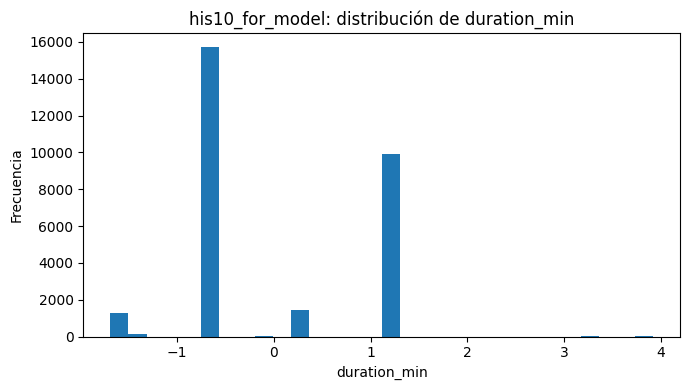

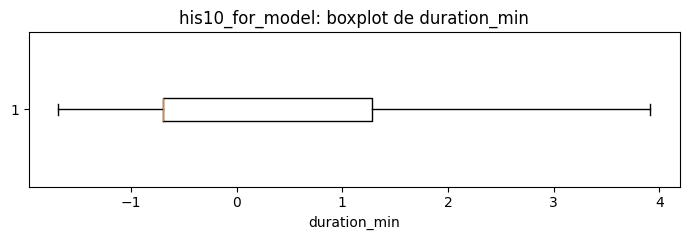

In [91]:
plt.figure(figsize=(7, 4))
plt.hist(his10_for_model['duration_min'], bins=30)
plt.title("his10_for_model: distribución de duration_min")
plt.xlabel("duration_min")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 2.5))
plt.boxplot(his10_for_model['duration_min'], vert=False)
plt.title("his10_for_model: boxplot de duration_min")
plt.xlabel('duration_min')
plt.tight_layout()
plt.show()

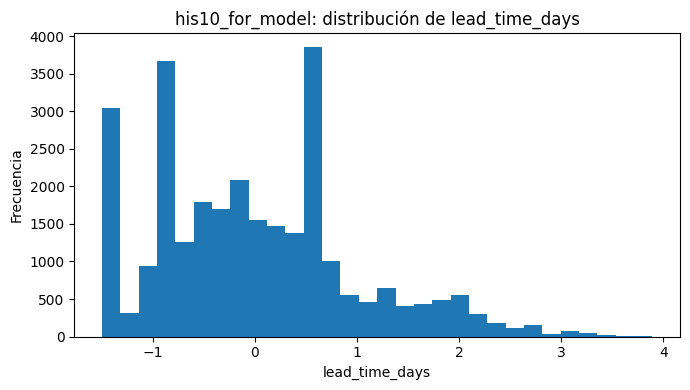

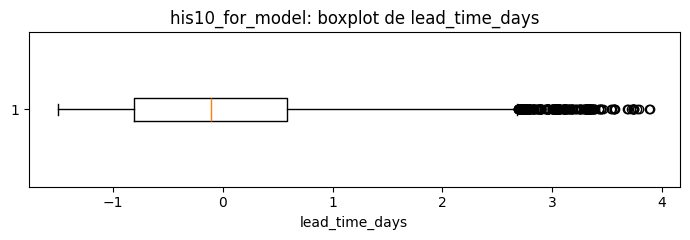

In [92]:
plt.figure(figsize=(7, 4))
plt.hist(his10_for_model['lead_time_days'], bins=30)
plt.title("his10_for_model: distribución de lead_time_days")
plt.xlabel("lead_time_days")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 2.5))
plt.boxplot(his10_for_model['lead_time_days'], vert=False)
plt.title("his10_for_model: boxplot de lead_time_days")
plt.xlabel('lead_time_days')
plt.tight_layout()
plt.show()

### Modelo

Se opta por ajustar un modelo de Gradient Boosting Machines del tipo LightGBM dado que este maneja bien bases de datos anchas y dispersas como esta y es eficiente computacionalmente al lidiar con las 464 columnas. Además, es rápido de entrenar y captura interacciones complejas entre variables. De igual forma, tiene parámetros nativos como scale_pos_weight que se puede ajustar para darle más peso a la clase minoritaria (el 25% que no asiste). La diferencia de usar LigthGBM y no XGBoost es que al usar One-Hot encoding y crear columnas que son mutuamente excluyentes, LightGBM identifica automáticamente estas variables dispersas y las empaqueta en una sola característica internamente sin perder información. XGBoost procesa las 464 columnas una por una mientras que LightGBM las comprime, reduciendo la dimensionalidad y acelerando el proceso, permitiendo capturar patrones complejos y alcanzar un mejor rendimiento predictivo mucho más rápido.

In [93]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report

def train_and_evaluate_lgbm(X, y, threshold):
    """
    Entrena un modelo LightGBM manejando el desbalanceo y calcula 
    las métricas de evaluación clave.
    """
    
    # 1. Separar en conjuntos de Entrenamiento y Prueba (80% / 20%)
    # stratify=y para mantener la proporción del 25% de ausentismo en ambos sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # 2. Calcular el peso para balancear las clases (scale_pos_weight)
    # Fórmula: (Número de casos Negativos) / (Número de casos Positivos)
    negatives = (y_train == 0).sum()
    positives = (y_train == 1).sum()
    scale_weight = negatives / positives
    
    print(f"Distribución de entrenamiento: 0s: {negatives}, 1s: {positives}")
    print(f"Parámetro scale_pos_weight calculado: {scale_weight:.2f}\n")

    # 3. Definir y entrenar el modelo LightGBM
    lgbm_model = lgb.LGBMClassifier(
        n_estimators=200,            # Número de árboles
        learning_rate=0.05,          # Tasa de aprendizaje
        max_depth=7,                 # Límite de profundidad para evitar sobreajuste
        num_leaves=31,               # Máximo de hojas en cada árbol
        scale_pos_weight=scale_weight, # Manejo de desbalanceo
        random_state=42,
        n_jobs=-1                    # Usar todos los núcleos del procesador
    )
    
    print("Entrenando el modelo LightGBM...")
    lgbm_model.fit(X_train, y_train)
    
    # 4. Predicciones
    # Predecir probabilidades (necesarias para AUC, PR-AUC y Thresholding)
    y_pred_proba = lgbm_model.predict_proba(X_test)[:, 1]
    
    # Predecir clases usando un umbral personalizado 
    y_pred_class = (y_pred_proba >= threshold).astype(int)

    # 5. Cálculo de Métricas solicitadas para HIS-10
    precision = precision_score(y_test, y_pred_class)
    recall = recall_score(y_test, y_pred_class)
    f1 = f1_score(y_test, y_pred_class)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)
    
    # 6. Mostrar resultados
    print('\n')
    print(f"MÉTRICAS DE EVALUACIÓN (Umbral Operativo: {threshold})")
    print('\n')
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"PR-AUC:    {pr_auc:.4f}")
    print(f"Precision: {precision:.4f} (De los que predijo que faltarían, ¿cuántos faltaron?)")
    print(f"Recall:    {recall:.4f} (De todos los que realmente faltaron, ¿cuántos detectó?)")
    print(f"F1-Score:  {f1:.4f} (Balance entre Precision y Recall)\n")
    
    print("Matriz de Confusión:")
    print(confusion_matrix(y_test, y_pred_class))
    
    # Devolver el modelo entrenado, probabilidades y test real para análisis posterior
    return lgbm_model, y_test, y_pred_proba

In [94]:
X = his10_for_model.drop(columns=['no_show'])
y = his10_for_model['no_show']

# Entrenamos y evaluamos 
lgbm_model, y_test_r, probas_predichas = train_and_evaluate_lgbm(X, y, threshold=0.5)

Distribución de entrenamiento: 0s: 17059, 1s: 5781
Parámetro scale_pos_weight calculado: 2.95

Entrenando el modelo LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 5781, number of negative: 17059
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011391 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 840
[LightGBM] [Info] Number of data points in the train set: 22840, number of used features: 290
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.253109 -> initscore=-1.082101
[LightGBM] [Info] Start training from score -1.082101
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]